In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures , OneHotEncoder , OrdinalEncoder , LabelEncoder , StandardScaler
from sklearn.linear_model import LinearRegression , Lasso , Ridge , ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error , mean_absolute_error , root_mean_squared_error , r2_score
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Dataset/Netflix.csv")

---
Understand the Dataset
---
---



In [ ]:
df.sample(5)

,show_id,title,release_type,genre,language,country,release_year,release_day,duration_minutes,number_of_seasons,...,budget_million_usd,marketing_spend_million_usd,cast_popularity_score,director_popularity_score,imdb_rating,critic_score,trailer_views_million,social_media_mentions_k,subscription_plan_popularity,watch_hours_million
24063,NFX024064,Exclusive empowering utilization,Movie,Romance,English,South Korea,2018,Saturday,138,0,...,41.97,12.72,9.36,5.39,7.6,70.6,52.03,214.04,Premium,238.61
17308,NFX017309,Persevering 24hour time-frame,Series,Fantasy,French,Spain,2024,Monday,97,4,...,46.42,17.79,4.52,8.15,5.6,51.7,43.32,176.62,Basic,298.78
968,NFX000969,Balanced asymmetric Graphic Interface,Movie,Romance,Hindi,India,2020,Tuesday,109,0,...,47.62,27.88,9.97,2.05,7.9,88.6,77.70,286.68,Basic,346.58
10581,NFX010582,Reverse-engineered mission-critical flexibility,Movie,Drama,Korean,South Korea,2023,Sunday,121,0,...,73.97,24.72,7.01,8.64,7.6,71.0,65.86,241.41,Standard,354.72
10802,NFX010803,User-centric actuating policy,Series,Thriller,Hindi,Spain,2025,Saturday,107,5,...,59.62,35.00,1.21,2.42,6.1,60.1,71.66,226.85,Standard,413.50


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   show_id                       25000 non-null  object 
 1   title                         25000 non-null  object 
 2   release_type                  25000 non-null  object 
 3   genre                         25000 non-null  object 
 4   language                      25000 non-null  object 
 5   country                       25000 non-null  object 
 6   release_year                  25000 non-null  int64  
 7   release_day                   25000 non-null  object 
 8   duration_minutes              25000 non-null  int64  
 9   number_of_seasons             25000 non-null  int64  
 10  total_episodes                25000 non-null  int64  
 11  budget_million_usd            25000 non-null  float64
 12  marketing_spend_million_usd   25000 non-null  float64
 13  c

In [ ]:
df.describe()

,release_year,duration_minutes,number_of_seasons,total_episodes,budget_million_usd,marketing_spend_million_usd,cast_popularity_score,director_popularity_score,imdb_rating,critic_score,trailer_views_million,social_media_mentions_k,watch_hours_million
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,2020.455960,109.646280,1.977200,20.320560,45.234921,17.003701,5.494800,5.515754,6.460124,64.593880,41.621048,184.511095,254.140916
std,3.460483,24.510603,2.445755,25.417469,19.594853,9.761252,2.597302,2.608319,1.291745,15.043583,18.973568,73.500029,82.719162
min,2015.000000,60.000000,0.000000,1.000000,5.000000,0.750000,1.000000,1.000000,1.700000,20.000000,1.000000,5.000000,20.000000
25%,2017.000000,93.000000,0.000000,1.000000,31.580000,9.690000,3.230000,3.240000,5.600000,54.400000,27.770000,131.680000,195.490000
50%,2020.000000,109.000000,0.000000,1.000000,45.060000,15.290000,5.500000,5.530000,6.500000,64.500000,39.140000,179.585000,247.975000
75%,2023.000000,126.000000,4.000000,36.000000,58.500000,22.920000,7.740000,7.760000,7.400000,74.900000,53.420000,231.705000,307.080000
max,2026.000000,227.000000,7.000000,98.000000,127.960000,65.520000,10.000000,10.000000,10.000000,100.000000,133.760000,500.000000,681.560000


In [ ]:
df.isna().sum()

,0
show_id,0
title,0
release_type,0
genre,0
language,0
country,0
release_year,0
release_day,0
duration_minutes,0
number_of_seasons,0


In [ ]:
df.duplicated().sum()

np.int64(0)

---
Exploratory Data Analysis (EDA)
---
---

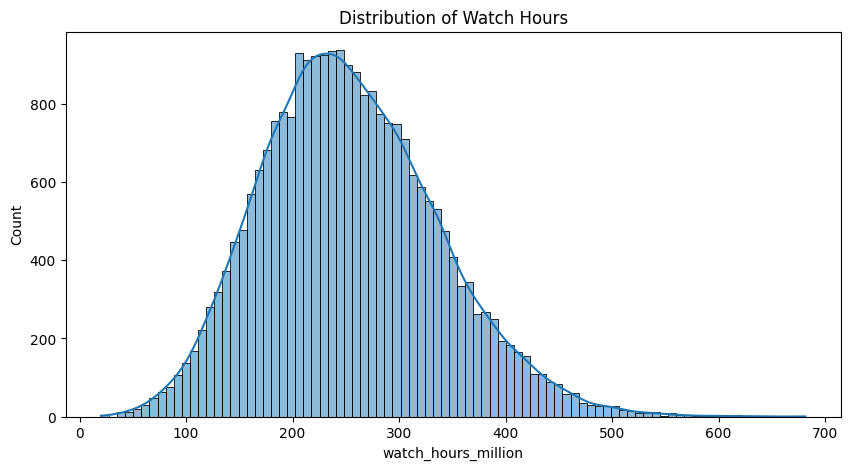

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df["watch_hours_million"],kde=True)
plt.title("Distribution of Watch Hours")
plt.show()

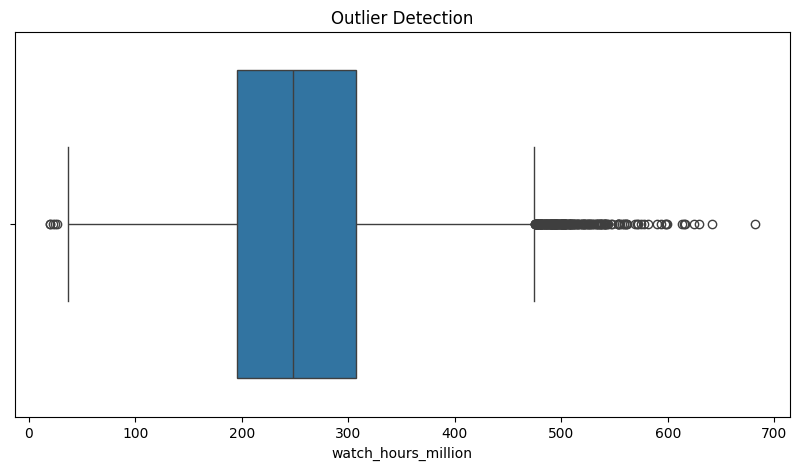

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x = df["watch_hours_million"])
plt.title("Outlier Detection")
plt.show()

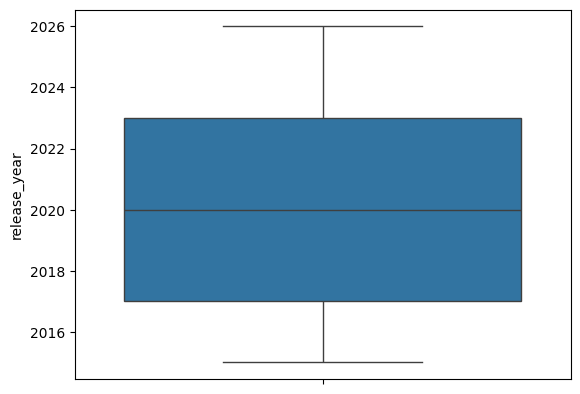

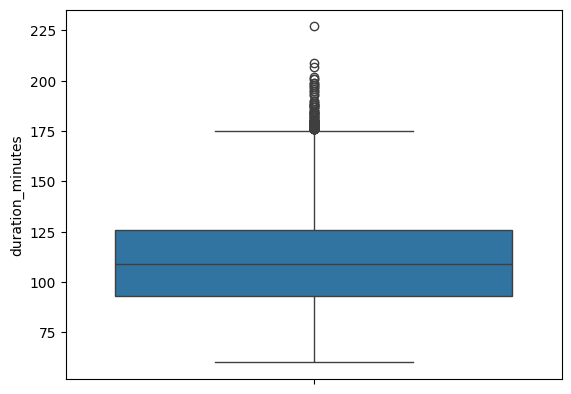

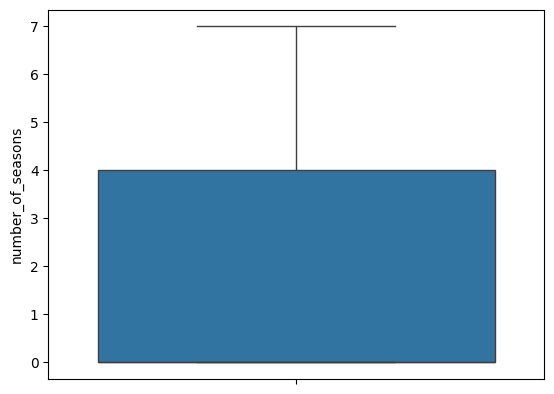

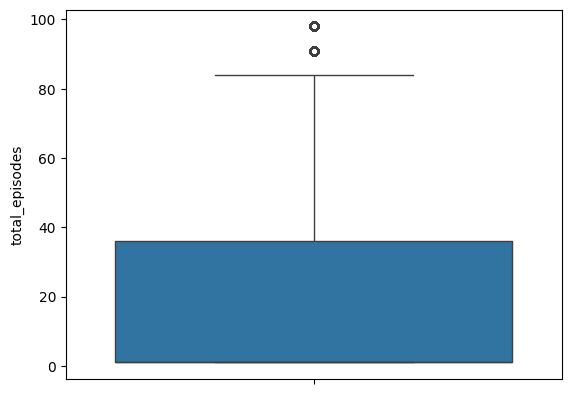

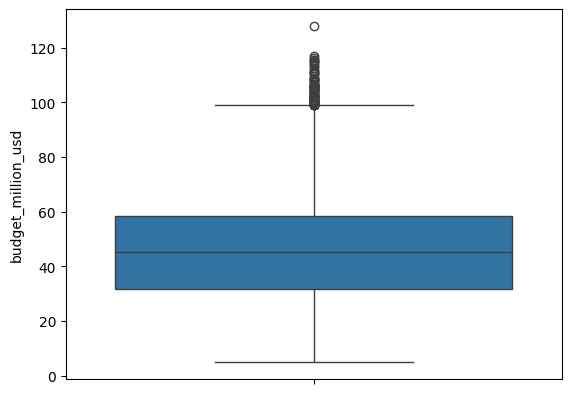

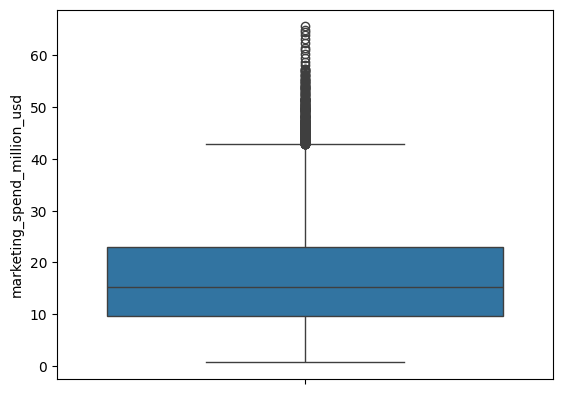

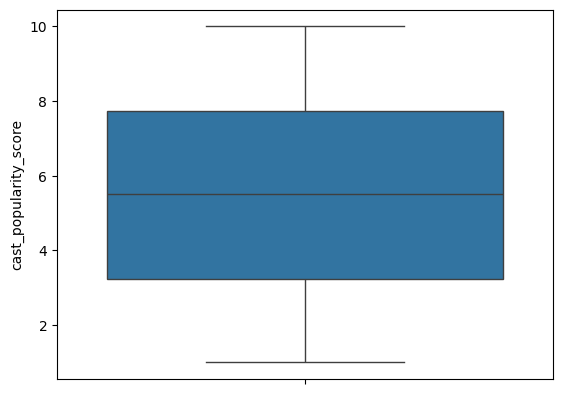

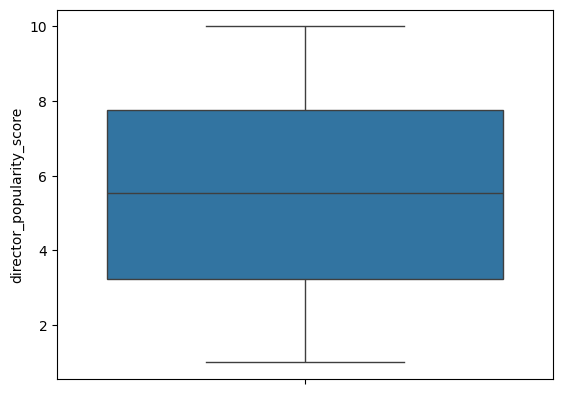

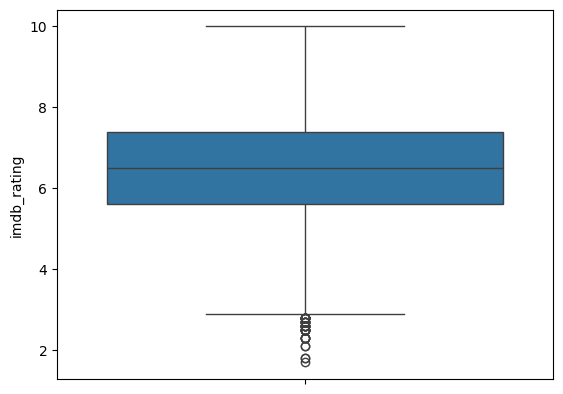

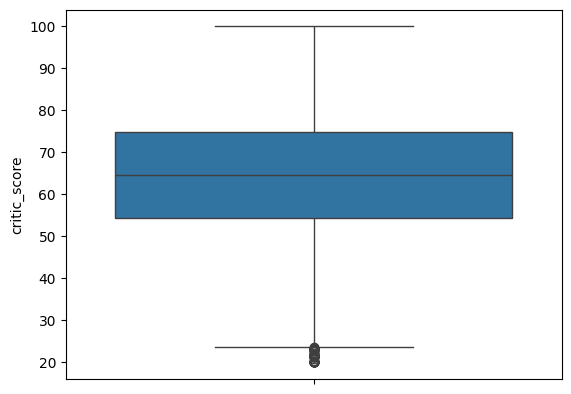

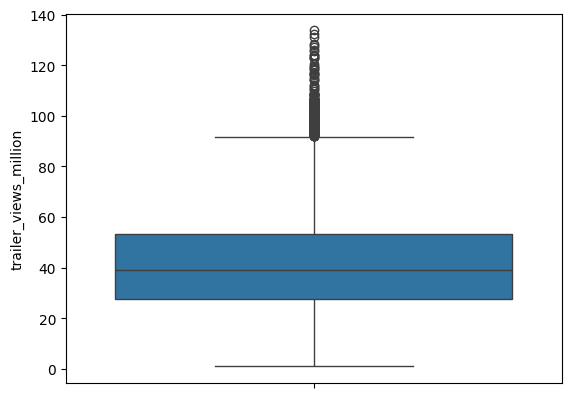

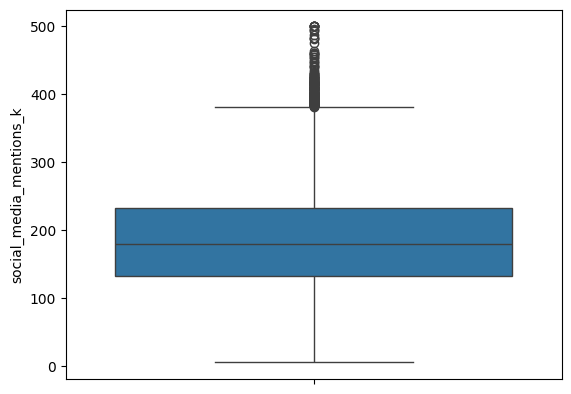

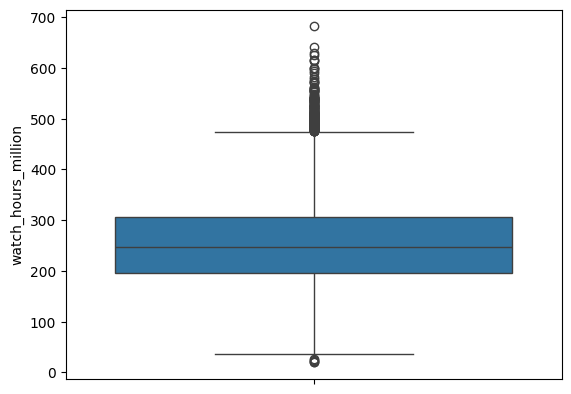

In [ ]:
col=[x for x in df.columns if df[x].dtypes==int or df[x].dtypes==float]

for i in col:
  sns.boxplot(df[i])
  plt.show()

In [ ]:
col=[x for x in df.columns if df[x].dtypes==int or df[x].dtypes==float]

for i in col:
  q1 = df[i].quantile(.25)
  q3 = df[i].quantile(.75)
  iqr = q3 - q1

  lower = q1 - (1.5*iqr)
  upper = q3 + (1.5*iqr)

  df = df[(df[i] > lower) & (df[i] < upper)]

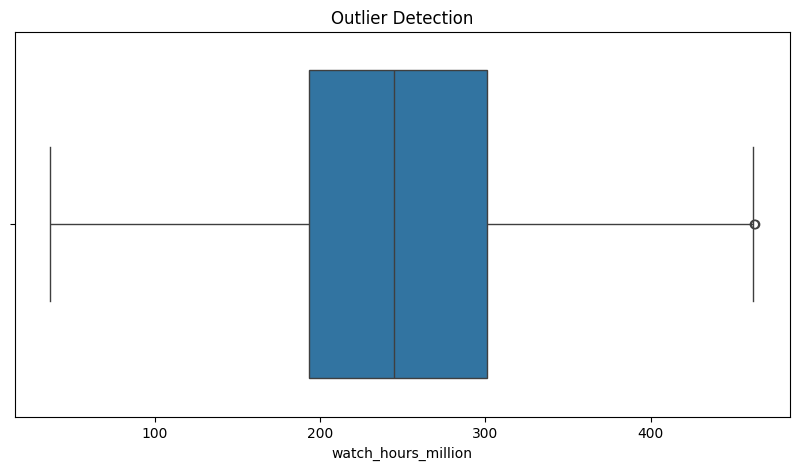

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x = df["watch_hours_million"])
plt.title("Outlier Detection")
plt.show()

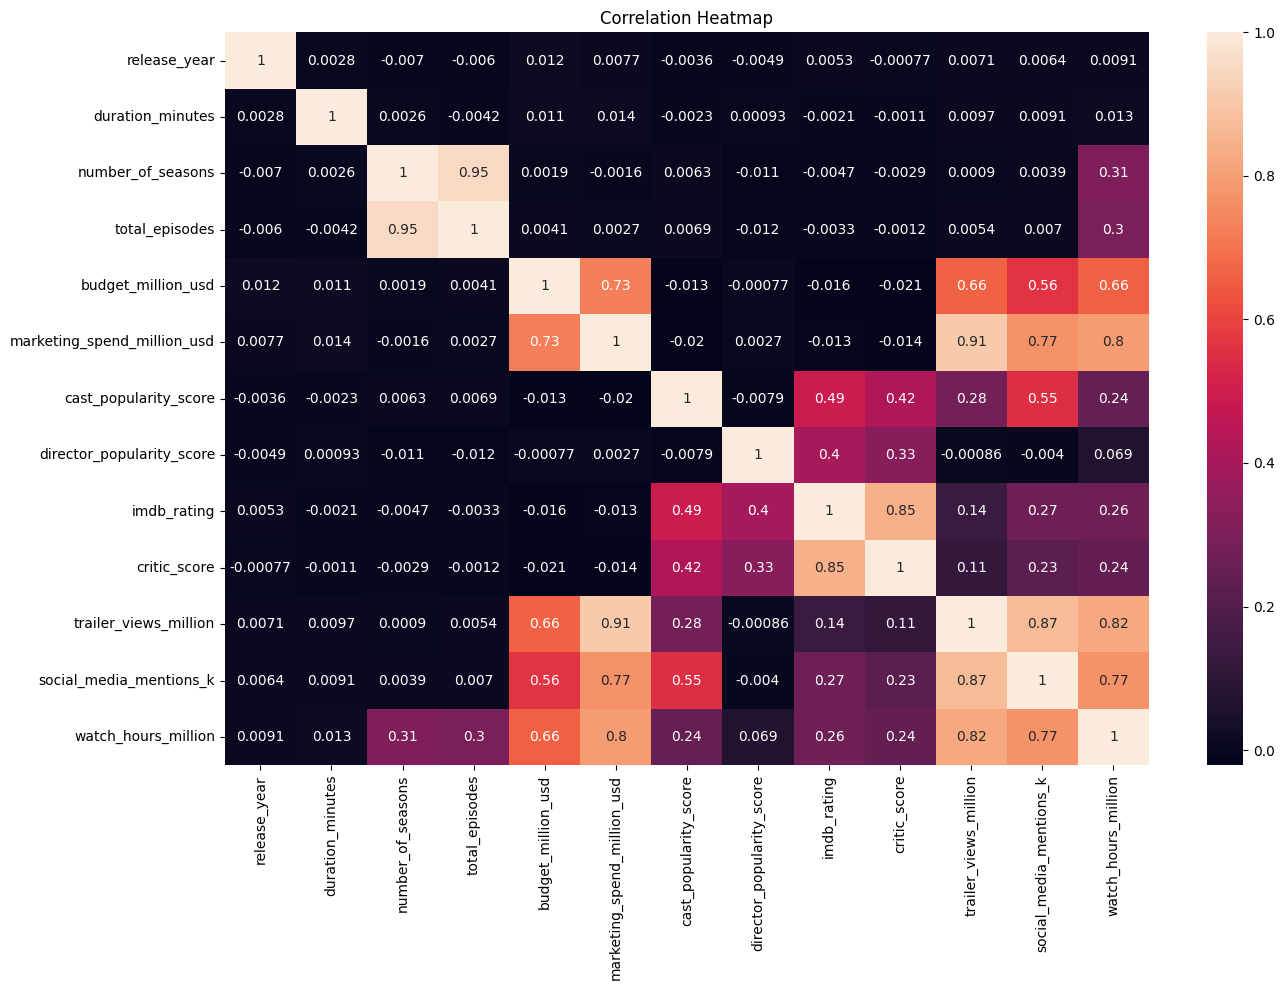

In [ ]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

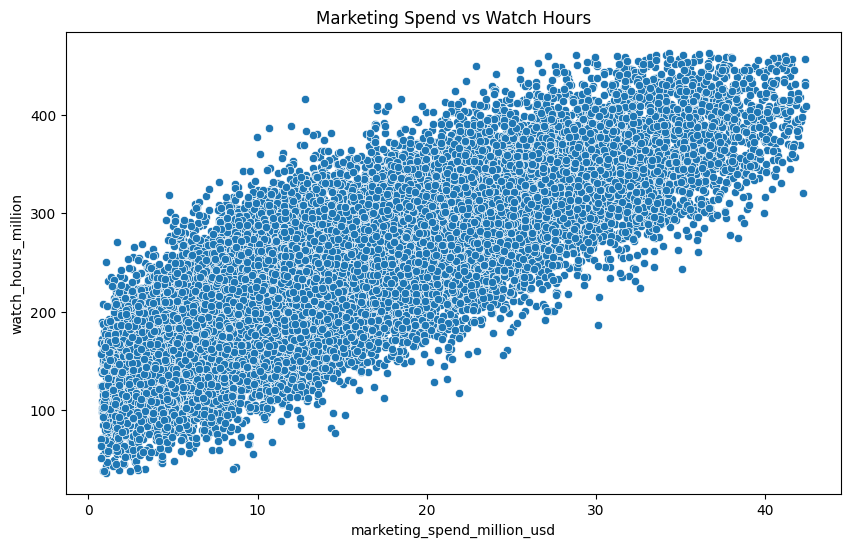

In [ ]:

plt.figure(figsize=(10,6))
sns.scatterplot(
    x=df['marketing_spend_million_usd'],
    y=df['watch_hours_million']
)
plt.title("Marketing Spend vs Watch Hours")
plt.show()


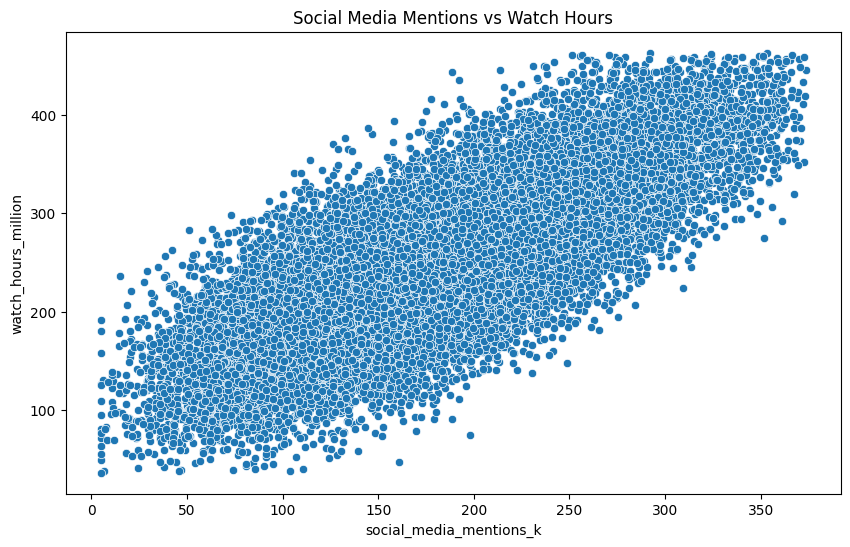

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=df['social_media_mentions_k'],
    y=df['watch_hours_million']
)
plt.title("Social Media Mentions vs Watch Hours")
plt.show()


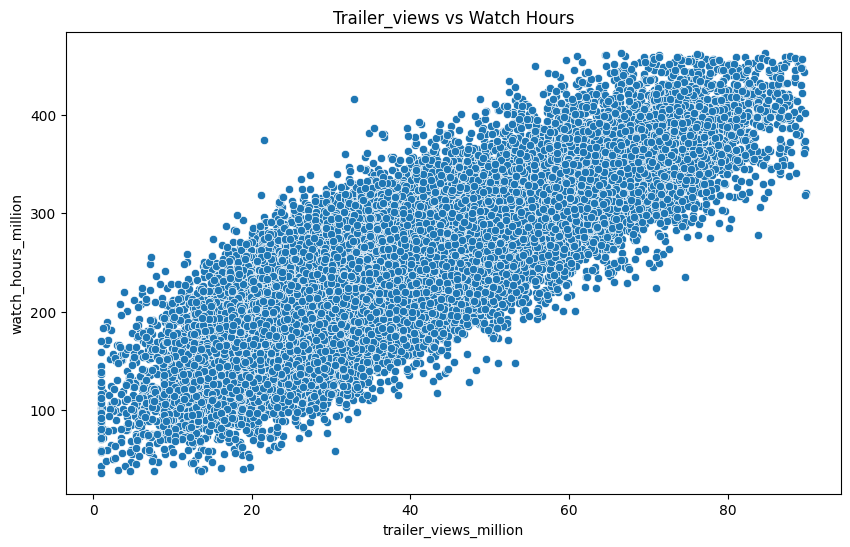

In [ ]:

plt.figure(figsize=(10,6))
sns.scatterplot(
    x=df['trailer_views_million'],
    y=df['watch_hours_million']
)
plt.title("Trailer_views vs Watch Hours")
plt.show()


---
Feature Engineering
---
---

In [ ]:
df.columns

Index(['show_id', 'title', 'release_type', 'genre', 'language', 'country',
       'release_year', 'release_day', 'duration_minutes', 'number_of_seasons',
       'total_episodes', 'budget_million_usd', 'marketing_spend_million_usd',
       'cast_popularity_score', 'director_popularity_score', 'imdb_rating',
       'critic_score', 'trailer_views_million', 'social_media_mentions_k',
       'subscription_plan_popularity', 'watch_hours_million'],
      dtype='object')

In [ ]:
df['budget_marketing_ratio'] = (
    df['budget_million_usd'] /
    (df['marketing_spend_million_usd'] + 1)
)

In [ ]:
df["popularity_score"] = (
    df["cast_popularity_score"] * 0.7 +
    df["director_popularity_score"] * 0.3
)

In [ ]:
df['episodes_per_season'] = (
    df['total_episodes'] /
    (df['number_of_seasons'] + 1)
)

df.head()

,show_id,title,release_type,genre,language,country,release_year,release_day,duration_minutes,number_of_seasons,...,director_popularity_score,imdb_rating,critic_score,trailer_views_million,social_media_mentions_k,subscription_plan_popularity,watch_hours_million,budget_marketing_ratio,popularity_score,episodes_per_season
0,NFX000001,Adaptive disintermediate alliance,Movie,Drama,French,South Korea,2020,Tuesday,116,0,...,2.40,5.9,67.1,57.27,243.33,Basic,274.30,2.009879,5.193,1.0
1,NFX000002,Re-contextualized transitional benchmark,Movie,Comedy,French,Japan,2023,Friday,107,0,...,5.72,4.9,50.8,5.89,45.36,Basic,102.28,5.241107,2.563,1.0
2,NFX000003,Adaptive asymmetric conglomeration,Series,Drama,English,USA,2016,Tuesday,94,4,...,9.54,5.8,55.7,28.20,95.87,Basic,208.64,4.034014,3.975,9.6
3,NFX000004,Persevering content-based architecture,Movie,Fantasy,Hindi,Japan,2016,Saturday,114,0,...,5.68,4.8,53.9,26.08,113.52,Premium,141.91,2.024119,4.371,1.0
5,NFX000006,Expanded context-sensitive throughput,Movie,Documentary,Spanish,South Korea,2022,Tuesday,137,0,...,4.23,3.8,36.6,25.34,128.80,Basic,124.04,1.871170,2.438,1.0


---
# Define Features and Target
---


In [ ]:

x = df.drop(columns=[
    'watch_hours_million',
    'show_id',
    'title',
    "release_year",
    "duration_minutes",
    "director_popularity_score"
])

y = df['watch_hours_million']


In [ ]:
X

,release_type,genre,language,country,release_day,number_of_seasons,total_episodes,budget_million_usd,marketing_spend_million_usd,cast_popularity_score,director_popularity_score,imdb_rating,critic_score,trailer_views_million,social_media_mentions_k,subscription_plan_popularity,budget_marketing_ratio,popularity_score,episodes_per_season
0,Movie,Drama,French,South Korea,Tuesday,0,1,54.93,26.33,6.39,2.40,5.9,67.1,57.27,243.33,Basic,2.009879,5.193,1.0
1,Movie,Comedy,French,Japan,Friday,0,1,26.52,4.06,1.21,5.72,4.9,50.8,5.89,45.36,Basic,5.241107,2.563,1.0
2,Series,Drama,English,USA,Tuesday,4,48,47.44,10.76,1.59,9.54,5.8,55.7,28.20,95.87,Basic,4.034014,3.975,9.6
3,Movie,Fantasy,Hindi,Japan,Saturday,0,1,21.82,9.78,3.81,5.68,4.8,53.9,26.08,113.52,Premium,2.024119,4.371,1.0
5,Movie,Documentary,Spanish,South Korea,Tuesday,0,1,26.87,13.36,1.67,4.23,3.8,36.6,25.34,128.80,Basic,1.871170,2.438,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,Series,Documentary,Hindi,India,Monday,1,13,40.31,14.08,3.39,9.61,6.2,64.9,24.46,132.79,Basic,2.673077,5.256,6.5
24996,Series,Comedy,French,South Korea,Thursday,1,13,57.16,25.83,2.82,4.96,4.8,54.0,52.09,206.98,Premium,2.130451,3.462,6.5
24997,Movie,Fantasy,French,Spain,Monday,0,1,46.94,26.20,3.88,1.58,5.2,48.4,56.03,225.38,Premium,1.725735,3.190,1.0
24998,Movie,Thriller,German,South Korea,Wednesday,0,1,50.72,27.68,1.54,8.96,6.7,71.0,47.76,153.36,Standard,1.768480,3.766,1.0


In [ ]:
categorical_features = X.select_dtypes(include="object").columns
numerical_features = X.select_dtypes(exclude="object").columns

print(categorical_features)
print(numerical_features)

Index(['release_type', 'genre', 'language', 'country', 'release_day',
       'subscription_plan_popularity'],
      dtype='object')
Index(['number_of_seasons', 'total_episodes', 'budget_million_usd',
       'marketing_spend_million_usd', 'cast_popularity_score',
       'director_popularity_score', 'imdb_rating', 'critic_score',
       'trailer_views_million', 'social_media_mentions_k',
       'budget_marketing_ratio', 'popularity_score', 'episodes_per_season'],
      dtype='object')


---
# Data Preprocessing
---

In [ ]:
numerical_transformer = Pipeline(
    steps=[
        ("Imputer",SimpleImputer(strategy="median")),
        ("Standard Scaler",StandardScaler())
    ]
)
ordinal_col = ['subscription_plan_popularity']

label_cols = [
    'release_type',
    'genre',
    'language',
    'country',
    'release_day'
]

ordinal_transformer = Pipeline(
    steps=[
        ("Imputer",SimpleImputer(strategy="most_frequent")),
        ("Ordinal",OrdinalEncoder(categories=[["Basic","Standard","Premium"]]))
    ]
)
label_transformer = Pipeline(
    steps=[
        ("Imputer",SimpleImputer(strategy="most_frequent")),
        ("LabelEncoder",OrdinalEncoder())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("Numeric_Transformer",numerical_transformer,numerical_features),
        ("Ordinal_Transformer",ordinal_transformer,ordinal_col),
        ("Label_Transformer",label_transformer,label_cols)
    ]
)

---
# Train - Test Split
---

In [ ]:
x_train , x_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)


Training Shape: (19039, 19)
Testing Shape: (4760, 19)


-----
# Linear Regression
-----

In [ ]:
linear_model = Pipeline(
    steps=[
        ("Preprocessing",preprocessor),
        ("Linear Model",LinearRegression())
    ]
)

linear_model.fit(x_train,y_train)
linear_predictions = linear_model.predict(x_test)

In [ ]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_predictions)


n = x_test.shape[0]
p = x_test.shape[1]

linear_r2_adj = 1 - ((1 -linear_r2)*(n-1) / (n - p - 1))

print("Linear Regression Metrics")
print("MAE:", linear_mae)
print("MSE:", linear_mse)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)
print("Adjusted R²:", linear_adj_r2)


Linear Regression Metrics
MAE: 24.508622964219445
MSE: 932.9672025303516
RMSE: 30.544511823408662
R²: 0.8404530503955628
Adjusted R²: 0.8398135162093847


---
# Polynomial Regression
---

In [ ]:
poly_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])

poly_pipeline.fit(x_train, y_train)

poly_predictions = poly_pipeline.predict(x_test)


In [ ]:
poly_mae = mean_absolute_error(y_test, poly_predictions)
poly_mse = mean_squared_error(y_test, poly_predictions)
poly_rmse = np.sqrt(poly_mse)
poly_r2 = r2_score(y_test, poly_predictions)

poly_adj_r2 = 1 - ((1 - poly_r2) * (n - 1) / (n - p - 1))

print("Polynomial Regression Metrics")
print("MAE:", poly_mae)
print("MSE:", poly_mse)
print("RMSE:", poly_rmse)
print("R²:", poly_r2)
print("Adjusted R²:", poly_adj_r2)


Polynomial Regression Metrics
MAE: 24.622014822859754
MSE: 941.0274324557032
RMSE: 30.676170433346194
R²: 0.8390746685036674
Adjusted R²: 0.838429609158007


---
# Ridge Regression
---

In [ ]:
ridge_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

ridge_model.fit(x_train, y_train)

ridge_predictions = ridge_model.predict(x_test)


In [ ]:

ridge_mae = mean_absolute_error(y_test, ridge_predictions)
ridge_mse = mean_squared_error(y_test, ridge_predictions)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_predictions)

ridge_adj_r2 = 1 - ((1 - ridge_r2) * (n - 1) / (n - p - 1))

print("Ridge Regression Metrics")
print("MAE:", ridge_mae)
print("MSE:", ridge_mse)
print("RMSE:", ridge_rmse)
print("R²:", ridge_r2)
print("Adjusted R²:", ridge_adj_r2)


Ridge Regression Metrics
MAE: 24.508544392991205
MSE: 932.9615271470362
RMSE: 30.54441891978036
R²: 0.8404540209442524
Adjusted R²: 0.8398144906484593


---
# Lasso Regression
---

In [ ]:
lasso_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=0.1))
])

lasso_model.fit(x_train, y_train)

lasso_predictions = lasso_model.predict(x_test)

In [ ]:

lasso_mae = mean_absolute_error(y_test, lasso_predictions)
lasso_mse = mean_squared_error(y_test, lasso_predictions)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_predictions)

lasso_adj_r2 = 1 - ((1 - lasso_r2) * (n - 1) / (n - p - 1))

print("Lasso Regression Metrics")
print("MAE:", lasso_mae)
print("MSE:", lasso_mse)
print("RMSE:", lasso_rmse)
print("R²:", lasso_r2)
print("Adjusted R²:", lasso_adj_r2)


Lasso Regression Metrics
MAE: 24.503210399098904
MSE: 932.6192030906316
RMSE: 30.53881469688422
R²: 0.8405125618649059
Adjusted R²: 0.8398732662268116


---
# Elastic Net Regression
---

In [ ]:
elastic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', ElasticNet(alpha=0.1, l1_ratio=0.5))
])

elastic_model.fit(x_train, y_train)

elastic_predictions = elastic_model.predict(x_test)


In [ ]:

elastic_mae = mean_absolute_error(y_test, elastic_predictions)
elastic_mse = mean_squared_error(y_test, elastic_predictions)
elastic_rmse = np.sqrt(elastic_mse)
elastic_r2 = r2_score(y_test, elastic_predictions)

elastic_adj_r2 = 1 - ((1 - elastic_r2) * (n - 1) / (n - p - 1))

print("Elastic Net Metrics")
print("MAE:", elastic_mae)
print("MSE:", elastic_mse)
print("RMSE:", elastic_rmse)
print("R²:", elastic_r2)
print("Adjusted R²:", elastic_adj_r2)


Elastic Net Metrics
MAE: 24.546318357731746
MSE: 937.0748074263785
RMSE: 30.611677631687854
R²: 0.8397506078771507
Adjusted R²: 0.839108257993114


---
# KNN Regressor
---

In [ ]:
kreg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor(n_neighbors=20))
])

kreg_model.fit(x_train, y_train)

kreg_model_predictions = kreg_model.predict(x_test)


In [ ]:

kr_mae = mean_absolute_error(y_test, kreg_model_predictions)
kr_mse = mean_squared_error(y_test, kreg_model_predictions)
kr_rmse = np.sqrt(kr_mse)
kr_r2 = r2_score(y_test, kreg_model_predictions)

kr_adj_r2 = 1 - ((1 - kr_r2) * (n - 1) / (n - p - 1))

print("Lasso Regression Metrics")
print("MAE:", kr_mae)
print("MSE:", kr_mse)
print("RMSE:", kr_rmse)
print("R²:", kr_r2)
print("Adjusted R²:", kr_adj_r2)


Lasso Regression Metrics
MAE: 28.391826365546216
MSE: 1261.5316484608718
RMSE: 35.51804679963232
R²: 0.7842651640963324
Adjusted R²: 0.7834004042055793


---
# Model Comparison
---

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Polynomial Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Elastic Net',
        "KNN Regressor"
    ],
    'MAE': [
        linear_mae,
        poly_mae,
        ridge_mae,
        lasso_mae,
        elastic_mae,
        kr_mae
    ],
    'MSE': [
        linear_mse,
        poly_mse,
        ridge_mse,
        lasso_mse,
        elastic_mse,
        kr_mse
    ],
    'RMSE': [
        linear_rmse,
        poly_rmse,
        ridge_rmse,
        lasso_rmse,
        elastic_rmse,
        kr_rmse
    ],
    'R2 Score': [
        linear_r2,
        poly_r2,
        ridge_r2,
        lasso_r2,
        elastic_r2,
        kr_r2
    ]
})

results.sort_values(by='R2 Score', ascending=False)

,Model,MAE,MSE,RMSE,R2 Score
3,Lasso Regression,24.503210,932.619203,30.538815,0.840513
2,Ridge Regression,24.508544,932.961527,30.544419,0.840454
0,Linear Regression,24.508623,932.967203,30.544512,0.840453
4,Elastic Net,24.546318,937.074807,30.611678,0.839751
1,Polynomial Regression,24.622015,941.027432,30.676170,0.839075
5,KNN Regressor,28.391826,1261.531648,35.518047,0.784265


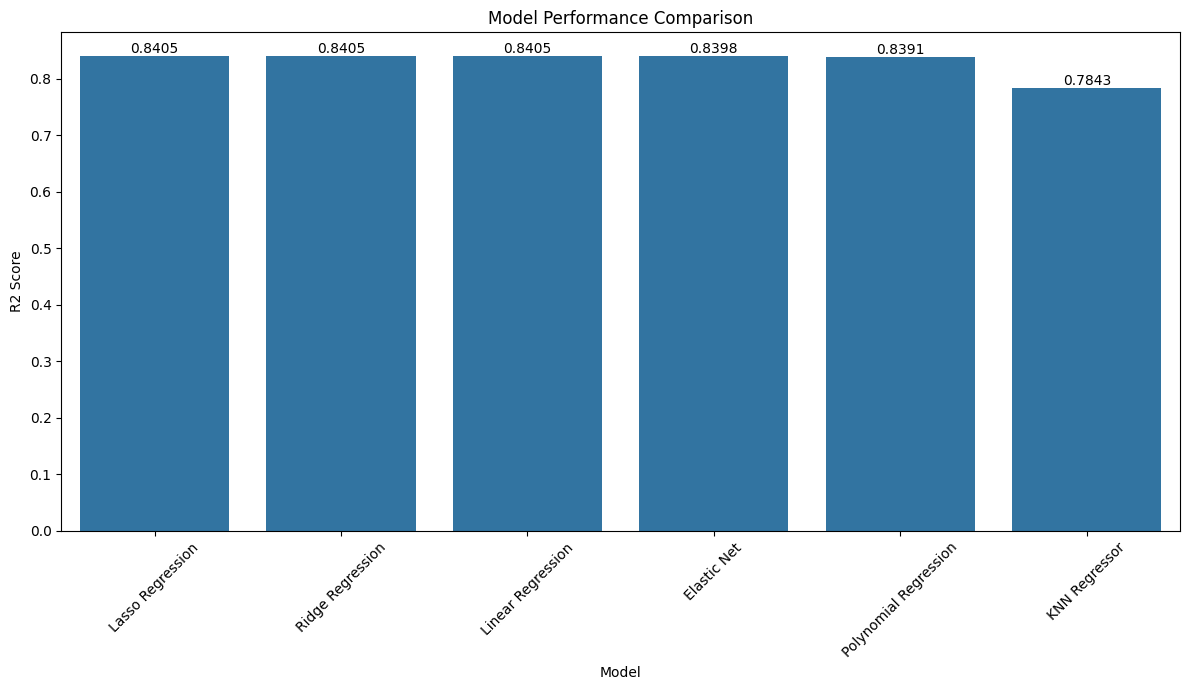

In [ ]:
plt.figure(figsize=(12,7))

ax = sns.barplot(
    x='Model',
    y='R2 Score',
    data=results.sort_values(by='R2 Score', ascending=False)
)

ax.bar_label(ax.containers[0], fmt='%.4f')

plt.xticks(rotation=45)
plt.title("Model Performance Comparison")
plt.tight_layout()
plt.show()